# 00 - From noise to data: diffusion and flow-matching foundations

This notebook builds the visual vocabulary used by the remaining notes. The
audience is expected to know Python and vectors, but not stochastic calculus.

**Learning goals**

1. Explain what a generative model learns and distinguish sampling from reconstruction.
2. Recognize a forward noising path and a reverse generative path.
3. Read a time-dependent vector field as arrows that move points.
4. Explain the flow-matching training pair `(x_t, x_data - x_noise)`.
5. Distinguish a model, a denoiser, and a numerical sampler.

The toy dataset has three labeled clusters, but the generative model in later
notebooks will be trained **without labels**. Labels are retained only to test
post-hoc steering.


In [1]:
import sys
from pathlib import Path

NOTES_DIR = Path.cwd()
if not (NOTES_DIR / "toy_notes.py").exists():
    NOTES_DIR = Path("notebooks/toy_data")
sys.path.insert(0, str(NOTES_DIR.resolve()))

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from toy_notes import *

SEED = 2026
set_seed(SEED)
device = choose_device()
print(environment_summary(device))


{'torch': '2.9.1+cu128', 'device': 'cuda', 'gpu': 'NVIDIA RTX A6000', 'cuda': '12.8'}


## 1. What is a generative model?

A generative model learns a **sampling procedure**. It is given a finite set of
training examples and learns how to create new samples with similar
distribution-level structure. This differs from a classifier, which receives a
sample and predicts a label, and from reconstruction, which estimates the clean
version of one particular observed item.

For the flow model in these notes:

- an easy source distribution supplies fresh Gaussian noise;
- a neural network learns a time-dependent velocity;
- an ODE sampler follows that velocity from noise to a generated endpoint.

The neural network alone is therefore not the complete generator. The source
distribution, trained velocity model, and sampler work together. During
generation there is no paired clean target to reconstruct: each fresh noise
seed starts a new sample.


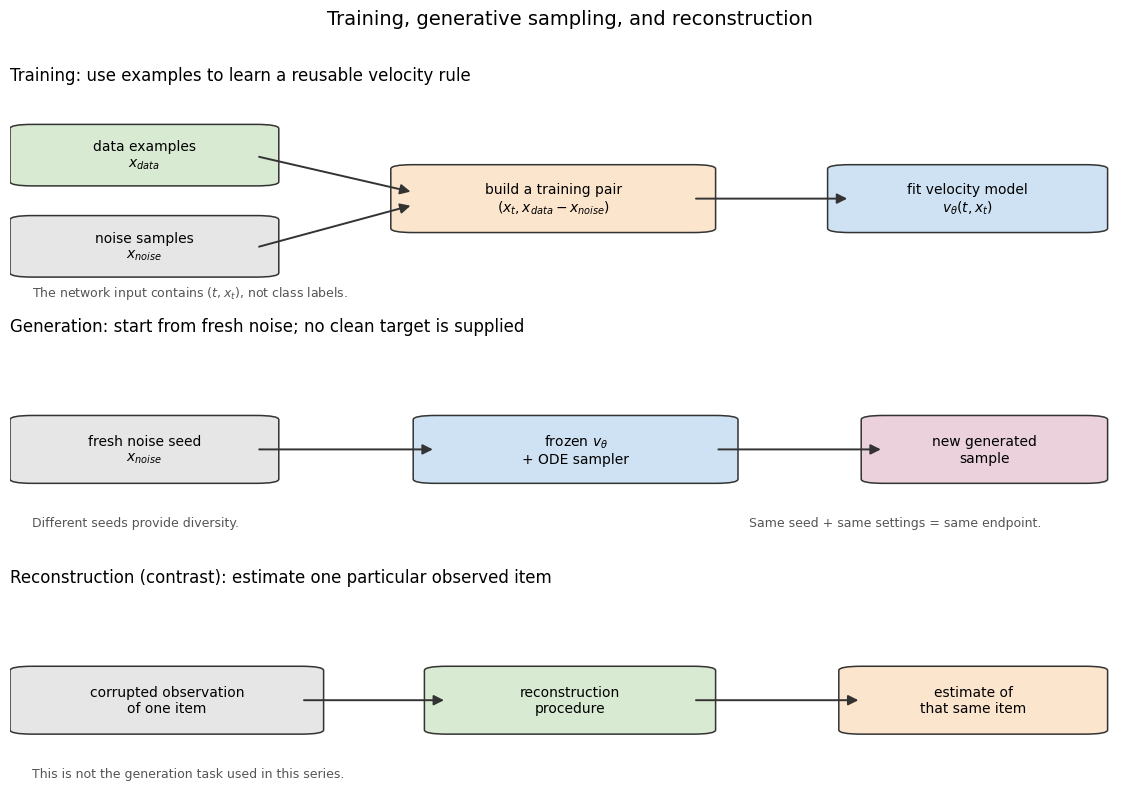

In [2]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

def process_box(ax, xy, width, height, text, color):
    patch = FancyBboxPatch(
        xy, width, height,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        facecolor=color, edgecolor="#333333", linewidth=1.1,
    )
    ax.add_patch(patch)
    ax.text(xy[0] + width / 2, xy[1] + height / 2, text, ha="center", va="center", fontsize=10)

def process_arrow(ax, start, end):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=15, linewidth=1.4, color="#333333"))

fig, axes = plt.subplots(3, 1, figsize=(11.5, 8.0))
for ax in axes:
    ax.set(xlim=(0, 1), ylim=(0, 1))
    ax.axis("off")

axes[0].set_title("Training: use examples to learn a reusable velocity rule", loc="left", fontsize=12)
process_box(axes[0], (0.02, 0.56), 0.20, 0.25, "data examples\n$x_{data}$", "#D9EAD3")
process_box(axes[0], (0.02, 0.13), 0.20, 0.25, "noise samples\n$x_{noise}$", "#E7E6E6")
process_box(axes[0], (0.36, 0.34), 0.25, 0.28, "build a training pair\n$(x_t, x_{data}-x_{noise})$", "#FCE5CD")
process_box(axes[0], (0.75, 0.34), 0.21, 0.28, "fit velocity model\n$v_\\theta(t,x_t)$", "#CFE2F3")
process_arrow(axes[0], (0.22, 0.68), (0.36, 0.51))
process_arrow(axes[0], (0.22, 0.25), (0.36, 0.45))
process_arrow(axes[0], (0.61, 0.48), (0.75, 0.48))
axes[0].text(0.02, 0.02, "The network input contains $(t,x_t)$, not class labels.", fontsize=9, color="#555555")

axes[1].set_title("Generation: start from fresh noise; no clean target is supplied", loc="left", fontsize=12)
process_box(axes[1], (0.02, 0.34), 0.20, 0.28, "fresh noise seed\n$x_{noise}$", "#E7E6E6")
process_box(axes[1], (0.38, 0.34), 0.25, 0.28, "frozen $v_\\theta$\n+ ODE sampler", "#CFE2F3")
process_box(axes[1], (0.78, 0.34), 0.18, 0.28, "new generated\nsample", "#EAD1DC")
process_arrow(axes[1], (0.22, 0.48), (0.38, 0.48))
process_arrow(axes[1], (0.63, 0.48), (0.78, 0.48))
axes[1].text(0.02, 0.12, "Different seeds provide diversity.", fontsize=9, color="#555555")
axes[1].text(0.66, 0.12, "Same seed + same settings = same endpoint.", fontsize=9, color="#555555")

axes[2].set_title("Reconstruction (contrast): estimate one particular observed item", loc="left", fontsize=12)
process_box(axes[2], (0.02, 0.34), 0.24, 0.28, "corrupted observation\nof one item", "#E7E6E6")
process_box(axes[2], (0.39, 0.34), 0.22, 0.28, "reconstruction\nprocedure", "#D9EAD3")
process_box(axes[2], (0.76, 0.34), 0.20, 0.28, "estimate of\nthat same item", "#FCE5CD")
process_arrow(axes[2], (0.26, 0.48), (0.39, 0.48))
process_arrow(axes[2], (0.61, 0.48), (0.76, 0.48))
axes[2].text(0.02, 0.12, "This is not the generation task used in this series.", fontsize=9, color="#555555")

fig.suptitle("Training, generative sampling, and reconstruction", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Unconditional, conditional, and post-hoc control

- An **unconditional** generator models all training examples without receiving
  a requested class. That is the model trained here.
- A **conditional** generator receives extra information, such as a class label
  or text prompt, during training and generation.
- **Post-hoc steering** keeps a trained generator frozen and modifies the
  sampling computation. Notebooks `03`--`05` study this third setting.

Random noise is useful because it is easy to sample and supplies a different
starting state for each output. A deterministic sampler can still generate a
diverse collection: it maps different initial noise seeds to different
endpoints.


## 2. A dataset we can see

A probability distribution describes which regions are likely and how often
different kinds of samples occur. Images live in thousands or millions of
dimensions, where that structure is difficult to draw. Here every sample has
only two coordinates, so a large scatter plot makes cluster locations,
frequencies, shapes, and spread directly visible. The three colors play the
role of semantic classes.


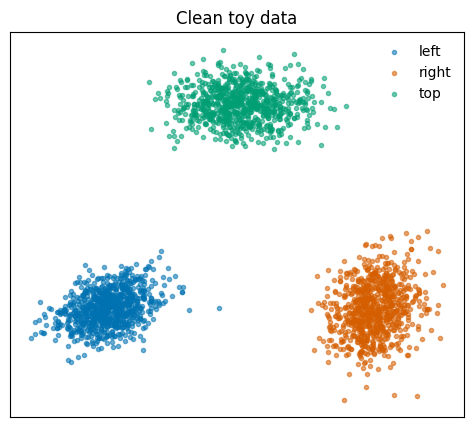

In [3]:
clean, labels = sample_labeled_mixture(2400, device=device)
fig, ax = plt.subplots(figsize=(6, 5))
plot_labeled_points(clean, labels, ax=ax, title="Clean toy data")
ax.legend(frameon=False)
plt.show()


## 3. Forward noising

First sample base noise, then use the linear path

$$x_{noise}=s\epsilon,\qquad \epsilon\sim\mathcal N(0,I),$$

$$x_t=(1-t)x_{noise}+t x_{data},\qquad s=1.8.$$

- At `t=1`, the point is clean data.
- At `t=0`, the point is Gaussian noise.
- Lower `t` therefore means higher noise in this notebook series.

A diffusion model learns to undo a noising process. Flow matching learns the
velocity of a path between the same endpoints.

### Diffusion and flow matching in one table

| Family | Typical learned quantity | Generation step |
|---|---|---|
| Diffusion model | noise, score, or a denoised estimate | repeatedly remove noise with a stochastic or deterministic sampler |
| Flow-matching model | velocity along a chosen probability path | integrate an ODE from the source distribution to data |

Both are time-dependent generative models. Here `t` indexes position along the
noise-to-data path; it is not elapsed computer time. We use flow matching
because the two-dimensional velocity arrows and complete trajectories are easy
to draw, then connect the same ideas to diffusion denoisers and steering.


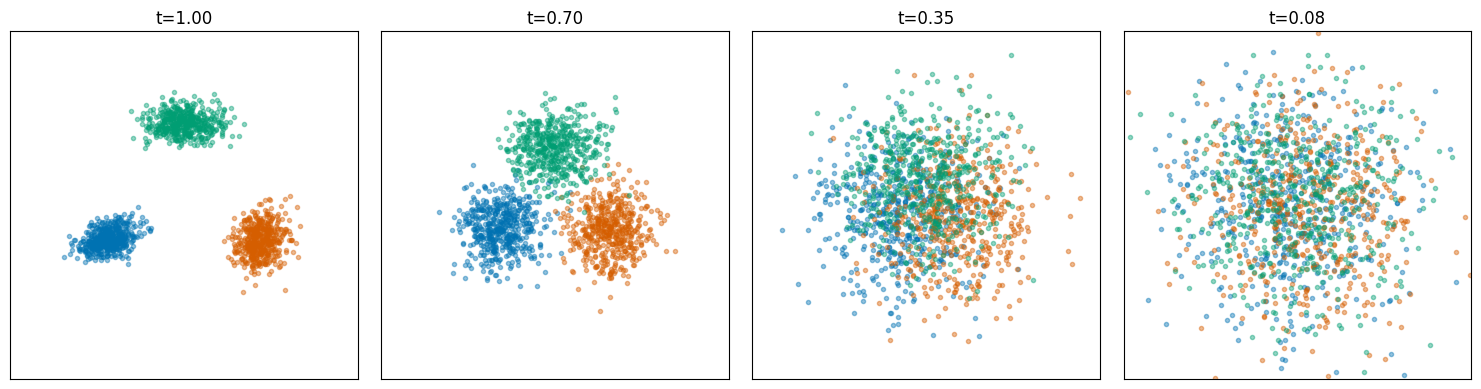

In [4]:
set_seed(SEED)
clean_small, labels_small = sample_labeled_mixture(1500, device=device)
fixed_noise = sample_base(clean_small.shape[0], device=device)

times = [1.0, 0.70, 0.35, 0.08]
fig, axes = plt.subplots(1, len(times), figsize=(15, 3.8))
for ax, t_value in zip(axes, times):
    t = torch.full((clean_small.shape[0],), t_value, device=device)
    noisy = forward_noising(clean_small, t, fixed_noise)
    plot_labeled_points(noisy, labels_small, ax=ax, title=f"t={t_value:.2f}", alpha=0.42)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
plt.tight_layout()
plt.show()


## 4. What flow matching predicts

Choose a noise point `x_noise`, a data point `x_data`, and a time `t`. Along the
straight conditional path, the target velocity is simply

$$u_t = x_{data} - x_{noise}.$$

Training repeatedly asks a neural network to predict this arrow from only
`(x_t, t)`. Because many endpoint pairs can pass near the same `x_t`, the
network learns an average velocity field, not a memorized arrow for each pair.
The pair-specific target is available while constructing training examples but
is not available during generation.


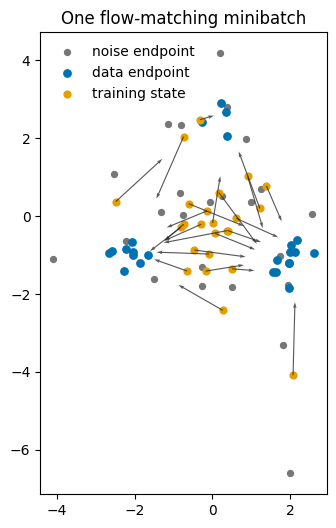

In [5]:
set_seed(SEED + 1)
x_data, pair_labels = sample_labeled_mixture(24, device=device)
x_noise = sample_base(24, device=device)
t_value = 0.42
x_t = forward_noising(x_data, torch.full((24,), t_value, device=device), x_noise)
u_t = x_data - x_noise

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_noise[:, 0].cpu(), x_noise[:, 1].cpu(), s=18, color="#777777", label="noise endpoint")
ax.scatter(x_data[:, 0].cpu(), x_data[:, 1].cpu(), s=28, color="#0072B2", label="data endpoint")
ax.scatter(x_t[:, 0].cpu(), x_t[:, 1].cpu(), s=24, color="#E69F00", label="training state")
ax.quiver(
    x_t[:, 0].cpu(), x_t[:, 1].cpu(),
    u_t[:, 0].cpu(), u_t[:, 1].cpu(),
    angles="xy", scale_units="xy", scale=3.2, width=0.004, color="#222222", alpha=0.75,
)
ax.set_title("One flow-matching minibatch")
ax.set_aspect("equal")
ax.legend(frameon=False)
plt.show()


## 5. Objects that must not be confused

| Object | Job | Learned? |
|---|---|---|
| Training dataset | Supplies examples of the distribution to imitate | No |
| Base distribution | Supplies fresh, easy-to-sample Gaussian noise | No |
| Noising path | Defines intermediate training states | Chosen by us |
| Neural model | Predicts the local velocity `v_theta(t,x_t)` | Yes |
| Denoiser view | Converts velocity into a clean-data estimate | Derived from the model |
| Sampler | Numerically follows model predictions | Chosen by us |

In these notes, **generator** refers to the complete sampling procedure: base
distribution + trained neural model + sampler. Replacing Euler with RK4 changes
the sampler, not the learned model.

Notebook `01` trains the velocity model. Notebook `02` converts its velocity
prediction into a denoised estimate and compares deterministic samplers.

**Check your understanding**

1. What is visible at high noise: exact class details or only coarse structure?
2. Why is `x_data - x_noise` available during training but unavailable during generation?
3. Which component changes when Euler is replaced by RK4: the trained model or the sampler?
